In [1]:
import os
import warnings
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
Data_Path='./'

df_train=pd.read_csv(Data_Path+'train.csv')
df_test=pd.read_csv(Data_Path+'test.csv')

In [3]:
df_sample=df_train[df_train['breath_id']<5].reset_index(drop=True)

In [4]:
print(df_train.head())
print(df_train.info())

   id  breath_id   R   C  time_step       u_in  u_out   pressure
0   1          1  20  50   0.000000   0.083334      0   5.837492
1   2          1  20  50   0.033652  18.383041      0   5.907794
2   3          1  20  50   0.067514  22.509278      0   7.876254
3   4          1  20  50   0.101542  22.808822      0  11.742872
4   5          1  20  50   0.135756  25.355850      0  12.234987
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6036000 entries, 0 to 6035999
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   breath_id  int64  
 2   R          int64  
 3   C          int64  
 4   time_step  float64
 5   u_in       float64
 6   u_out      int64  
 7   pressure   float64
dtypes: float64(3), int64(5)
memory usage: 368.4 MB
None


In [5]:
import torch
from torch.utils.data import Dataset

class VentilatorDataset(Dataset):
    def __init__(self, df):
        if "pressure" not in df.columns:
            df['pressure'] = 0

        self.df=df.groupby('breath_id').agg(list).reset_index()

        self.prepare_data()

    def __len__(self):
        return self.df.shape[0]

    def prepare_data(self):
        self.pressures=np.array(self.df['pressure'].values.tolist())

        rs=np.array(self.df['R'].values.tolist())
        cs=np.array(self.df['C'].values.tolist())
        u_ins=np.array(self.df['u_in'].values.tolist())

        self.u_outs=np.array(self.df['u_out'].values.tolist())

        self.inputs=np.concatenate([
            rs[:,None],
            cs[:,None],
            u_ins[:,None],
            np.cumsum(u_ins,1)[:,None],
            self.u_outs[:,None]
            ],1).transpose(0,2,1)

    def __getitem__(self,idx):
        data={
            "input":torch.tensor(self.inputs[idx],dtype=torch.float),
            "u_out":torch.tensor(self.u_outs[idx],dtype=torch.float),
            "p":torch.tensor(self.pressures[idx],dtype=torch.float)
        }

        return data

In [6]:
dataset=VentilatorDataset(df_train)
dataset[0,2]

{'input': tensor([20.0000, 50.0000, 22.5093, 40.9757,  0.0000]),
 'u_out': tensor(0.),
 'p': tensor(7.8763)}

In [7]:
import os
import random
import torch
import numpy as np

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED']=str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [8]:
def count_parameters(model, all=False):
    if all:
        return (p.suml() for p in model.parameters())
    else:
        return (p.suml() for p in model.parameters() if p.requires_grad)

In [9]:
def worker_init_fn(worker_id):
    np.random.seed(np.random.get_state()[1][0]+worker_id)

In [10]:
def save_model_weights(model, filename, verbose=1, cp_folder=""):
    if verbose:
        print(f"\n -> Saving weights to {os.path.join(cp_folder, filename)}\n")
    torch.save(model.state_dict(),os.path.join(cp_folder,filename))

In [11]:
import torch
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(
        self,
        input_dim=4,
        lstm_dim=128,
        dense_dim=128,
        logit_dim=128,
        num_classes=1):
        super().__init__()

        self.mlp=nn.Sequential(
            nn.Linear(input_dim,dense_dim*2),
            nn.ReLU(),
            nn.Linear(dense_dim*2,dense_dim),
            nn.ReLU(),
        )

        self.lstm=nn.LSTM(dense_dim,lstm_dim,batch_first=True,bidirectional=True, num_layers=1)

        self.logits=nn.Sequential(
            nn.Linear(lstm_dim*2,logit_dim),
            nn.ReLU(),
            nn.Linear(logit_dim,num_classes))

    def forward(self,x):
        features=self.mlp(x)
        features,_=self.lstm(features)
        pred=self.logits(features)
        return pred

In [12]:
def compute_metric(df, preds):
    y=np.array(df['pressure'].values.tolist())
    w=1-np.array(df['u_out'].values.tolist())

    assert y.shape==preds.shape and w.shape==y.shape,(y.shape,preds.shape,w.shape)

    mae=w*np.abs(y-preds)
    mae=mae.sum()/w.sum()

    return mae


class VentilatorLoss(nn.Module):
    def __call__(self,preds,y,u_out):
        w=1-u_out
        mae=w*(y-preds).abs()
        mae=mae.sum(-1)/w.sum(-1)

        return mae

In [13]:
import gc
import time
import torch
import numpy as np
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup

NUM_WORKERS=4

def fit(
    model,
    train_dataset,
    val_dataset,
    loss_name='L1Loss',
    optimizer='Adam',
    epochs=50,
    batch_size=32,
    val_bs=32,
    warmup_prop=0.1,
    lr=1e-3,
    num_classes=1,
    verbose=1,
    first_epoch_eval=0,
    device='cuda'
):
    avg_val_loss=0

    optimizer=getattr(torch.optim,optimizer)(model.parameters(),lr=lr)

    train_loader=DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        worker_init_fn=worker_init_fn)

    val_loader = DataLoader(
        val_dataset,
        batch_size=val_bs,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    # loss_fct=VentilatorLoss()
    loss_fct=torch.nn.L1Loss()

    num_warmup_steps=int(warmup_prop*epochs*len(train_loader))
    num_training_steps=int(epochs*len(train_loader))
    scheduler=get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps,num_training_steps
    )

    for epoch in range(epochs):
        model.train()                     #not train() defined later
        model.zero_grad()                 #explained further
        start_time=time.time()

        avg_loss=0
        for data in train_loader:
            pred=model(data['input'].to(device)).squeeze(-1)

            # loss=loss_fct(
            #     pred,
            #     data['p'].to(device),
            #     data['u_out'].to(device),
            # ).mean()
            loss=loss_fct(
                pred,
                data['p'].to(device),
            )
            loss.backward()
            avg_loss+=loss.item()/len(train_loader)

            optimizer.step()
            scheduler.step()

            for param in model.parameters():
                param.grad=None

        model.eval()
        mae,avg_val_loss=0,0
        preds=[]

        with torch.no_grad():
            for data in val_loader:
                pred = model(data['input'].to(device)).squeeze(-1)

                # loss = loss_fct(
                #     pred.detach(),
                #     data['p'].to(device),
                #     data['u_out'].to(device),
                # ).mean()
                loss = loss_fct(
                    pred.detach(),
                    data['p'].to(device),
                )
                avg_val_loss += loss.item() / len(val_loader)

                preds.append(pred.detach().cpu().numpy())

        preds = np.concatenate(preds, 0)
        mae = compute_metric(val_dataset.df, preds)

        elapsed_time = time.time() - start_time
        if (epoch + 1) % verbose == 0:
            elapsed_time = elapsed_time * verbose
            lr = scheduler.get_last_lr()[0]
            print(
                f"Epoch {epoch + 1:02d}/{epochs:02d} \t lr={lr:.1e}\t t={elapsed_time:.0f}s \t"
                f"loss={avg_loss:.3f}",
                end="\t",
            )

            if (epoch + 1 >= first_epoch_eval) or (epoch + 1 == epochs):
                print(f"val_loss={avg_val_loss:.3f}\tmae={mae:.3f}")
            else:
                print("")

    del (val_loader, train_loader, loss, data, pred)
    gc.collect()
    torch.cuda.empty_cache()

    return preds


In [14]:
def predict(
    model,
    dataset,
    batch_size=64,
    device="cuda"
):
    model.eval()

    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS
    )

    preds = []
    with torch.no_grad():
        for data in loader:
            pred = model(data['input'].to(device)).squeeze(-1)
            preds.append(pred.detach().cpu().numpy())

    preds = np.concatenate(preds, 0)
    return preds

In [15]:
def train(config, df_train, df_val, df_test, fold):
    seed_everything(config.seed)

    model = RNNModel(
        input_dim=config.input_dim,
        lstm_dim=config.lstm_dim,
        dense_dim=config.dense_dim,
        logit_dim=config.logit_dim,
        num_classes=config.num_classes,
    ).to(config.device)
    model.zero_grad()

    train_dataset = VentilatorDataset(df_train)
    val_dataset = VentilatorDataset(df_val)
    test_dataset = VentilatorDataset(df_test)

    n_parameters = count_parameters(model)

    print(f"    -> {len(train_dataset)} training breathes")
    print(f"    -> {len(val_dataset)} validation breathes")
    print(f"    -> {n_parameters} trainable parameters\n")

    pred_val = fit(
        model,
        train_dataset,
        val_dataset,
        loss_name=config.loss,
        optimizer=config.optimizer,
        epochs=config.epochs,
        batch_size=config.batch_size,
        val_bs=config.val_bs,
        lr=config.lr,
        warmup_prop=config.warmup_prop,
        verbose=config.verbose,
        first_epoch_eval=config.first_epoch_eval,
        device=config.device,
    )

    pred_test = predict(
        model,
        test_dataset,
        batch_size=config.val_bs,
        device=config.device
    )

    if config.save_weights:
        save_model_weights(
            model,
            f"{config.selected_model}_{fold}.pt",
            cp_folder="",
        )

    del (model, train_dataset, val_dataset, test_dataset)
    gc.collect()
    torch.cuda.empty_cache()

    return pred_val, pred_test

In [16]:
from sklearn.model_selection import GroupKFold

def k_fold(config, df, df_test):
    pred_oof=np.zeros(len(df))
    preds_test=[]

    gkf=GroupKFold(n_splits=config.k)
    splits=list(gkf.split(X=df,y=df,groups=df['breath_id']))

    for i,(train_index,val_index) in enumerate(splits):
        if i in config.selected_folds:
            print(f"\n-------------   Fold {i + 1} / {config.k}  -------------\n")

            df_train=df.iloc[train_index].copy().reset_index(drop=True)
            df_val=df.iloc[val_index].copy().reset_index(drop=True)

            pred_val,pred_test=train(config,df_train,df_val,df_test,i)

            pred_oof[val_index]=pred_val.flatten()
            preds_test.append(pred_test.flatten())

    print(f'\n -> CV MAE : {compute_metric(df, pred_oof) :.3f}')

    return pred_oof, np.mean(preds_test, 0)

In [17]:
class Config:

    # General
    seed = 42
    verbose = 1
    device = "cuda" if torch.cuda.is_available() else "cpu"
    save_weights = True

    # k-fold
    k = 5
    selected_folds = [0,1, 2,3, 4]

    # Model
    selected_model = 'rnn'
    input_dim = 5

    dense_dim = 512
    lstm_dim = 512
    logit_dim = 512
    num_classes = 1

    # Training
    loss = "L1Loss"  # not used
    optimizer = "Adam"
    batch_size = 128
    epochs = 5

    lr = 1e-3
    warmup_prop = 0

    val_bs = 256
    first_epoch_eval = 0

In [18]:
pred_oof, pred_test = k_fold(
    Config,
    df_train,
    df_test,
)


-------------   Fold 1 / 5  -------------

    -> 60360 training breathes
    -> 15090 validation breathes
    -> <generator object count_parameters.<locals>.<genexpr> at 0x7f4797eca190> trainable parameters

Epoch 01/05 	 lr=8.0e-04	 t=10s 	loss=4.574	val_loss=3.410	mae=6.431
Epoch 02/05 	 lr=6.0e-04	 t=10s 	loss=2.690	val_loss=2.327	mae=3.884
Epoch 03/05 	 lr=4.0e-04	 t=10s 	loss=2.146	val_loss=1.973	mae=3.174
Epoch 04/05 	 lr=2.0e-04	 t=10s 	loss=1.667	val_loss=1.356	mae=1.994
Epoch 05/05 	 lr=0.0e+00	 t=10s 	loss=1.207	val_loss=1.116	mae=1.734

 -> Saving weights to rnn_0.pt


-------------   Fold 2 / 5  -------------

    -> 60360 training breathes
    -> 15090 validation breathes
    -> <generator object count_parameters.<locals>.<genexpr> at 0x7f47d0340790> trainable parameters

Epoch 01/05 	 lr=8.0e-04	 t=10s 	loss=3.836	val_loss=2.612	mae=4.647
Epoch 02/05 	 lr=6.0e-04	 t=10s 	loss=2.301	val_loss=2.100	mae=3.502
Epoch 03/05 	 lr=4.0e-04	 t=10s 	loss=2.011	val_loss=1.850	mae=2

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


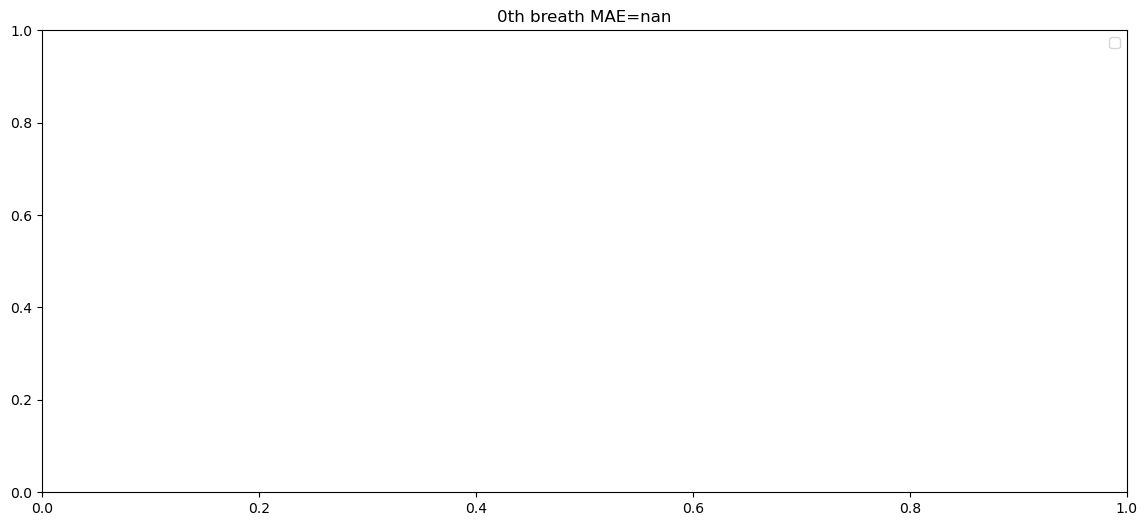

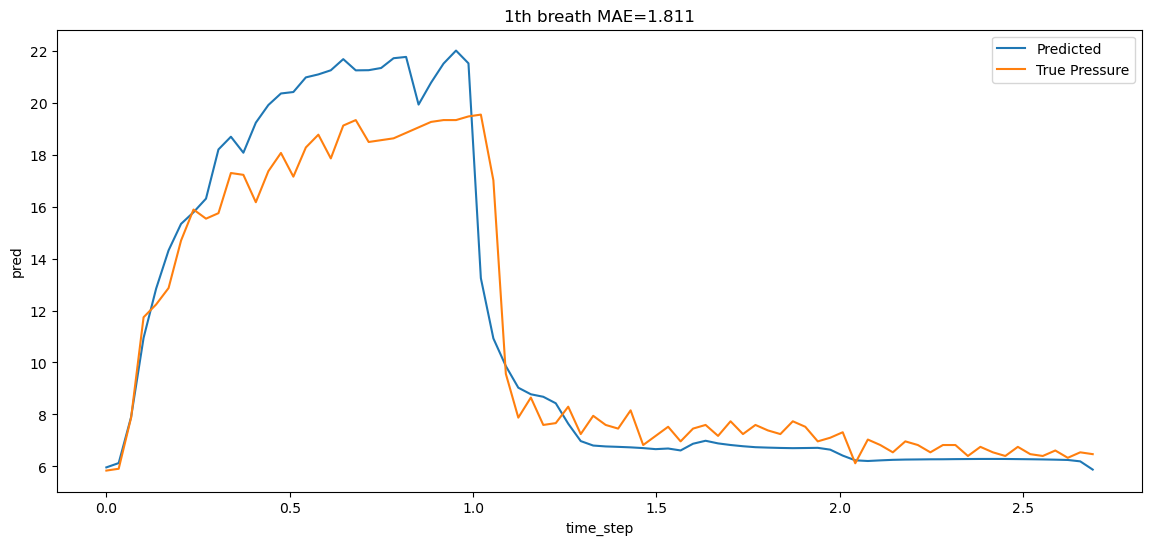

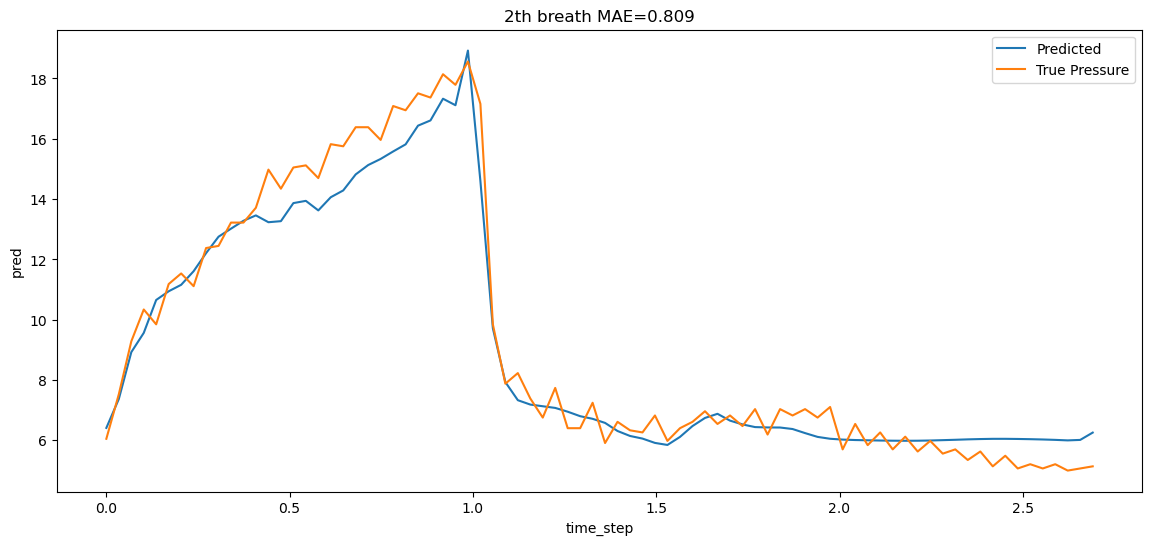

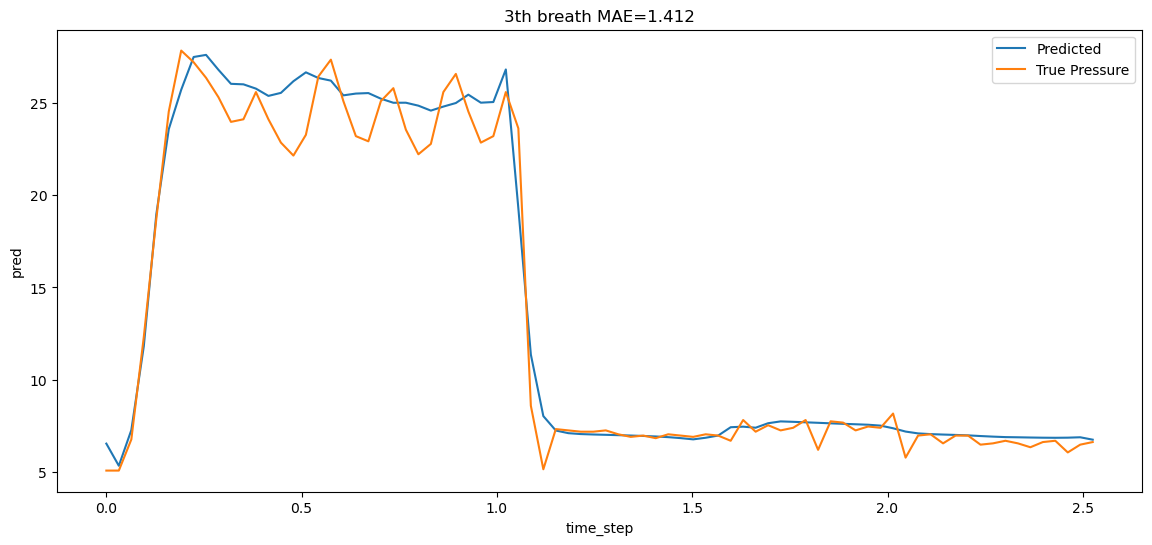

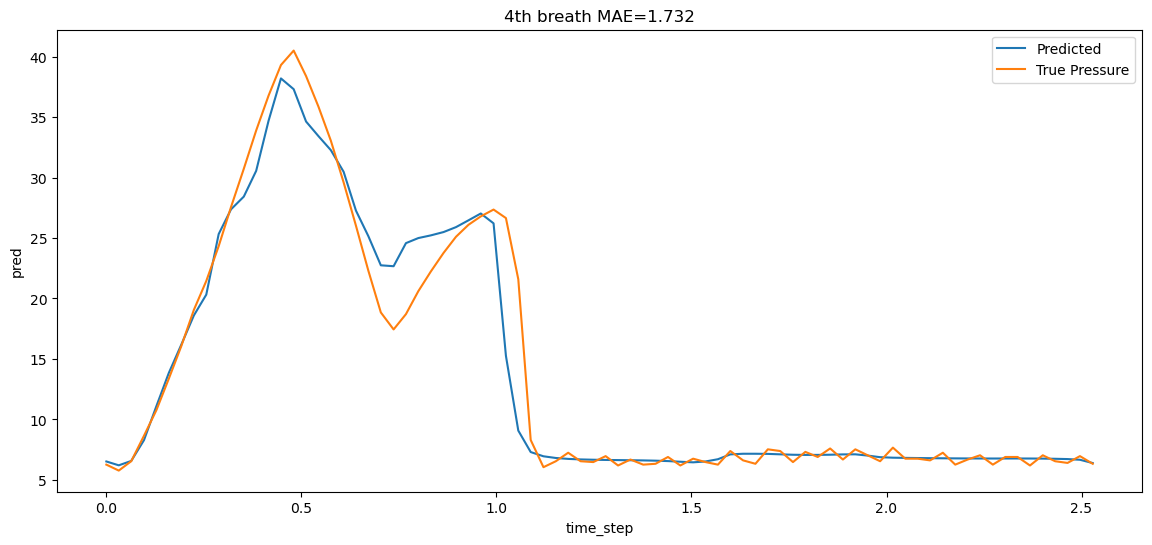

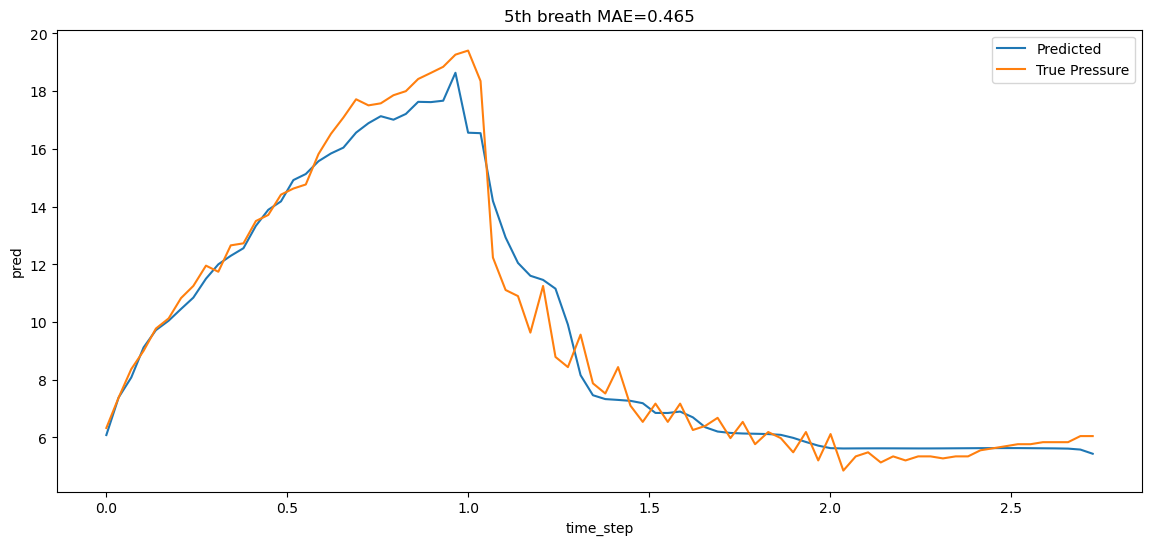

In [19]:
df_train['pred'] = pred_oof
for i in range(6):
    temp = df_train[df_train['breath_id'] == i]
    plt.figure(figsize=(14, 6))
    sns.lineplot(x=temp['time_step'], y=temp['pred'], label='Predicted')
    sns.lineplot(x=temp['time_step'], y=temp['pressure'], label='True Pressure')

    plt.title(f"{i}th breath MAE={compute_metric(temp, temp['pred']):.3f}")
    plt.legend()
    plt.show()

In [20]:
model = RNNModel(
    input_dim=5,
    lstm_dim=512,
    dense_dim=512,
    logit_dim=512,
    num_classes=1,
).to("cuda")

model.load_state_dict(torch.load("rnn_4.pt"))

<All keys matched successfully>

In [39]:
import torch
import numpy as np

# Augmentation 관련 설정
noise_level = 0.1  # 입력에 추가할 노이즈의 정도
threshold = 100.0     # 임계값 설정
shift_steps = 1     # 시간 시프트 스텝 수

# 모델을 평가 모드로 전환
model.cuda().eval()

# 증강 데이터셋을 저장할 리스트 초기화
augmented_data = []
accepted_count = 0  # 채택된 증강 데이터 개수 초기화
total_error_sum = 0

total_positive = 0    # 실제 기준에 부합하는 총 positive 케이스
true_positive = 0     # 모델이 채택하고 실제로 기준에 부합한 케이스
false_positive = 0    # 모델이 채택했으나 기준을 만족하지 않는 케이스
false_negative = 0    # 기준에 부합하지만 모델이 채택하지 않은 케이스

# 기존 데이터셋을 순회하며 노이즈 추가
for i in range(len(dataset)):
    # 원본 입력과 레이블(pressure) 추출
    original_input = dataset[i]['input']
    original_pressure = dataset[i]['p']

    # breath_id를 제외한 입력 부분에만 노이즈 추가
    noisy_input = original_input.clone()
    noisy_input += noise_level * torch.randn_like(noisy_input)
    # noisy_input_without_breath_id = noisy_input[:, 1:]  # breath_id 제외한 나머지 부분
    # noisy_input[:, 1:] = noisy_input_without_breath_id  # 원본 noisy_input에 갱신

    # 시간 시프트 추가
    # shifted_input = noisy_input.clone()
    # shifted_input[:, -1] = torch.roll(shifted_input[:, -1], shifts=shift_steps)  # 마지막 차원을 shift_steps 만큼 시프트
    # shifted_input = shifted_input.fillna(method="bfill")  # NaN 값 채우기


    # 모델 예측 (노이즈 추가된 입력에 대해 예측)
    noisy_input = noisy_input[None].to("cuda")  # 배치 차원 추가 및 CUDA로 전송
    with torch.no_grad():
        predicted_pressure = model(noisy_input).cpu().squeeze()  # 예측 결과

    # 원래 pressure와 노이즈 추가된 pressure 간의 차이 계산
    pressure_difference = torch.abs(predicted_pressure - original_pressure).sum()

    total_error_sum += pressure_difference.item()

    # 차이의 합이 threshold 이하인 경우에만 데이터 추가
    if pressure_difference <= threshold:
        augmented_data.append({
            "input": noisy_input.squeeze(0).cpu(),
            "u_out": dataset[i]['u_out'],
            "p": predicted_pressure  # 예측된 값을 사용할 수도 있음
        })
        accepted_count += 1  # 채택된 데이터 개수 증가

    # 기준에 부합하는 실제 positive 케이스
    if pressure_difference <= threshold:
        total_positive += 1
        if pressure_difference <= threshold:
            true_positive += 1  # 모델이 기준을 만족하는 데이터를 채택한 경우
        else:
            false_negative += 1  # 모델이 기준을 만족하는 데이터를 채택하지 않은 경우
    else:
        if pressure_difference <= threshold:
            false_positive += 1  # 모델이 기준을 만족하지 않는 데이터를 채택한 경우


total_positive = len(dataset)
true_positive = accepted_count
false_positive = 0
false_negative = total_positive - true_positive
precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
recall = true_positive / (total_positive) if total_positive > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


# 결과 출력
total_data = len(dataset)
print(f"기존 데이터셋 크기: {total_data}")
print(f"증강된 데이터 중 채택된 샘플 수: {accepted_count}")
print(f"채택 비율: {accepted_count / total_data * 100:.2f}%")
print(f"전체 데이터에서 오차 합산: {total_error_sum:.4f}")
print(f"전체 데이터에서 오차 합산 평균: {total_error_sum/(i+1):.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

기존 데이터셋 크기: 75450
증강된 데이터 중 채택된 샘플 수: 56487
채택 비율: 74.87%
전체 데이터에서 오차 합산: 5947797.4424
전체 데이터에서 오차 합산 평균: 78.8310
Precision: 1.0000
Recall: 0.7487
F1 Score: 0.8563


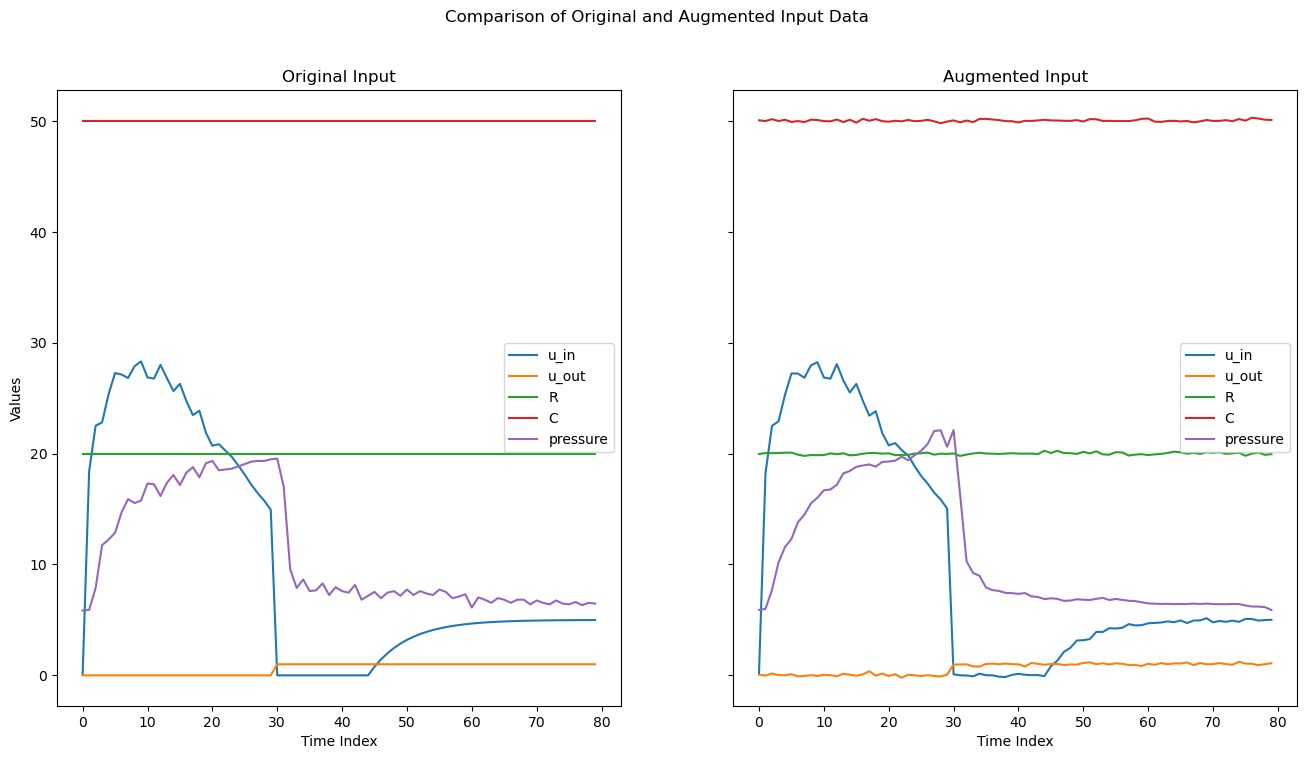

In [42]:
for i in range(len(dataset)):
    # 원본 입력과 레이블(pressure) 추출
    original_input = pd.DataFrame(dataset[i]['input'].numpy(), columns=['R', 'C', 'u_in', 'u_cum', 'u_out'])
    original_pressure = pd.DataFrame(dataset[i]['p'].numpy(), columns=['pressure'])

    augmented_input = pd.DataFrame(augmented_data[i]['input'].numpy(), columns=['R', 'C', 'u_in', 'u_cum', 'u_out'])
    augmented_pressure = pd.DataFrame(augmented_data[i]['p'].numpy(), columns=['pressure'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

    # Original input plot
    axes[0].plot(original_input.index, original_input['u_in'], label='u_in')
    axes[0].plot(original_input.index, original_input['u_out'], label='u_out')
    axes[0].plot(original_input.index, original_input['R'], label='R')
    axes[0].plot(original_input.index, original_input['C'], label='C')
    axes[0].plot(original_pressure.index, original_pressure['pressure'], label='pressure')
    axes[0].set_title('Original Input')
    axes[0].set_xlabel('Time Index')
    axes[0].set_ylabel('Values')
    axes[0].legend(loc='right')

    # Augmented input plot
    axes[1].plot(augmented_input.index, augmented_input['u_in'], label='u_in')
    axes[1].plot(augmented_input.index, augmented_input['u_out'], label='u_out')
    axes[1].plot(augmented_input.index, augmented_input['R'], label='R')
    axes[1].plot(augmented_input.index, augmented_input['C'], label='C')
    axes[1].plot(augmented_pressure.index, augmented_pressure['pressure'], label='pressure')
    axes[1].set_title('Augmented Input')
    axes[1].set_xlabel('Time Index')
    axes[1].legend(loc='right')

    plt.suptitle('Comparison of Original and Augmented Input Data')
    plt.show()

    break

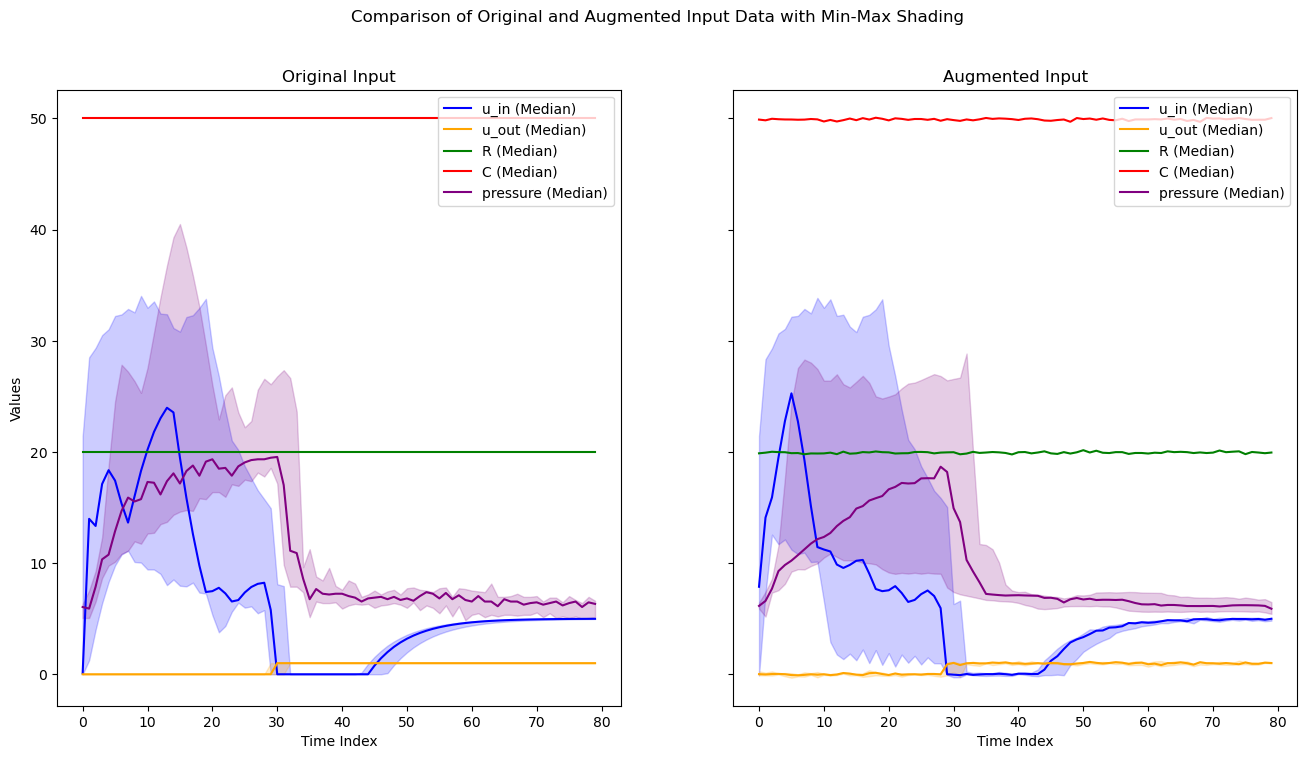

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Initialize lists to collect all time series data for each variable
original_u_in = []
original_u_out = []
original_R = []
original_C = []
original_pressure = []

augmented_u_in = []
augmented_u_out = []
augmented_R = []
augmented_C = []
augmented_pressure = []

# Collect all entries into respective lists
for i in range(0, 5):
    original_input = pd.DataFrame(dataset[i]['input'], columns=['R', 'C', 'u_in', 'u_cum', 'u_out'])
    original_pressure_data = pd.DataFrame(dataset[i]['p'], columns=['pressure'])

    augmented_input = pd.DataFrame(augmented_data[i]['input'], columns=['R', 'C', 'u_in', 'u_cum', 'u_out'])
    augmented_pressure_data = pd.DataFrame(augmented_data[i]['p'], columns=['pressure'])

    # Append each entry's time series data
    original_u_in.append(original_input['u_in'])
    original_u_out.append(original_input['u_out'])
    original_R.append(original_input['R'])
    original_C.append(original_input['C'])
    original_pressure.append(original_pressure_data['pressure'])

    augmented_u_in.append(augmented_input['u_in'])
    augmented_u_out.append(augmented_input['u_out'])
    augmented_R.append(augmented_input['R'])
    augmented_C.append(augmented_input['C'])
    augmented_pressure.append(augmented_pressure_data['pressure'])

# Function to plot with min-max shading and median line
def plot_with_shading(ax, data_list, label, color, fill_between=True):
    data_array = np.array(data_list)
    median = np.median(data_array, axis=0)
    min_val = np.min(data_array, axis=0)
    max_val = np.max(data_array, axis=0)

    if fill_between:
        ax.fill_between(range(len(median)), min_val, max_val, color=color, alpha=0.2)
    ax.plot(range(len(median)), median, color=color, label=f'{label} (Median)')

# Plot original and augmented data side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Plot original data with min-max shading
plot_with_shading(axes[0], original_u_in, 'u_in', 'blue')
plot_with_shading(axes[0], original_u_out, 'u_out', 'orange')
plot_with_shading(axes[0], original_R, 'R', 'green', fill_between=False)
plot_with_shading(axes[0], original_C, 'C', 'red', fill_between=False)
plot_with_shading(axes[0], original_pressure, 'pressure', 'purple')
axes[0].set_title('Original Input')
axes[0].set_xlabel('Time Index')
axes[0].set_ylabel('Values')
axes[0].legend(loc='upper right')

# Plot augmented data with min-max shading
plot_with_shading(axes[1], augmented_u_in, 'u_in', 'blue')
plot_with_shading(axes[1], augmented_u_out, 'u_out', 'orange')
plot_with_shading(axes[1], augmented_R, 'R', 'green', fill_between=False)
plot_with_shading(axes[1], augmented_C, 'C', 'red', fill_between=False)
plot_with_shading(axes[1], augmented_pressure, 'pressure', 'purple')
axes[1].set_title('Augmented Input')
axes[1].set_xlabel('Time Index')
axes[1].legend(loc='upper right')

# Set a super title for the comparison
plt.suptitle('Comparison of Original and Augmented Input Data with Min-Max Shading')
plt.show()
